# Vietnamese Text Preprocessing for Emotion Classification

This notebook performs comprehensive text preprocessing on Vietnamese emotion dataset:
- Replace emojis with Vietnamese emotion descriptors
- Replace non-standard abbreviations
- Substitute profanities with appropriate terms
- Remove extraneous spaces and special characters

**Note:** Stopwords are NOT removed because BERT-based models (like CafeBERT) rely on self-attention to understand context from ALL words, including stopwords like "không" (negation), "rất" (very), etc.

In [60]:
import pandas as pd
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Load the data
# df = pd.read_excel('/Users/giahuy/Documents/GitHub/topicmodeling/data/test_nor_811.xlsx')
df = pd.read_csv('/Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/train_1071_para_processed.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()   

Dataset shape: (7984, 3)
Columns: ['Sentence', 'Emotion', 'emotion_vn']


,Sentence,Emotion,emotion_vn
0,cho mình xin bài nhạc tên là gì với ạ,Other,khác
1,cho đáng đời con quỷ . về nhà lôi con nhà mày ...,Disgust,khó chịu
2,lo học đi . yêu đương lol gì hay lại thích học...,Disgust,khó chịu
3,uớc gì sau này về già vẫn có thể như cụ này :)),Enjoyment,vui vẻ
4,mỗi lần có video của con là cứ coi đi coi lại ...,Enjoyment,vui vẻ


In [61]:
# Check current columns and keep only Emotion and Sentence columns
print("Current columns:", df.columns.tolist())
print("Current shape:", df.shape)

# # Keep only Emotion and Sentence columns
# if 'Emotion' in df.columns and 'Sentence' in df.columns:
#     df = df[['Emotion', 'Sentence']]
#     print("Kept only Emotion and Sentence columns")
# else:
#     print("Warning: Required columns 'Emotion' and 'Sentence' not found!")
#      print("Available columns:", df.columns.tolist())

# print("New shape:", df.shape)
# print("New columns:", df.columns.tolist())
# df.head()


Current columns: ['Sentence', 'Emotion', 'emotion_vn']
Current shape: (7984, 3)


## 1. Define Preprocessing Components

In [62]:
# Vietnamese emoji to emotion descriptor mapping
EMOJI_TO_VIETNAMESE = {
    # Happy/Joy emojis
    '😀': 'vui vẻ', '😃': 'vui vẻ', '😄': 'vui vẻ', '😁': 'vui vẻ', '😆': 'vui vẻ',
    '😅': 'vui vẻ', '🤣': 'cười lớn', '😂': 'cười lớn', '🙂': 'mỉm cười', '🙃': 'mỉm cười',
    '😉': 'nháy mắt', '😊': 'hạnh phúc', '😇': 'thiên thần', '🥰': 'yêu thương',
    '😍': 'yêu thích', '🤩': 'ngưỡng mộ', '😘': 'hôn', '😗': 'hôn', '☺️': 'hạnh phúc',
    '😚': 'hôn', '😙': 'hôn', '🥲': 'vui buồn lẫn lộn',
    
    # Love emojis
    '❤️': 'yêu thương', '💕': 'yêu thương', '💗': 'yêu thương', '💖': 'yêu thương',
    '💘': 'yêu thương', '💝': 'yêu thương', '💞': 'yêu thương', '💓': 'yêu thương',
    '💜': 'yêu thương', '💙': 'yêu thương', '💚': 'yêu thương', '🧡': 'yêu thương',
    '🖤': 'yêu thương', '🤍': 'yêu thương', '🤎': 'yêu thương', '💛': 'yêu thương',
    
    # Sad emojis
    '😢': 'buồn bã', '😭': 'khóc', '😿': 'buồn bã', '😞': 'thất vọng',
    '😔': 'buồn bã', '😟': 'lo lắng', '😕': 'bối rối', '🙁': 'buồn bã',
    '☹️': 'buồn bã', '😣': 'đau khổ', '😖': 'khó chịu', '😫': 'mệt mỏi',
    '😩': 'mệt mỏi', '🥺': 'van xin', '😪': 'buồn ngủ', '😥': 'lo lắng',
    
    # Angry emojis
    '😠': 'tức giận', '😡': 'tức giận', '🤬': 'tức giận', '😤': 'bực tức',
    '💢': 'tức giận', '👿': 'tức giận', '😈': 'tinh nghịch',
    
    # Fear/Surprise emojis
    '😨': 'sợ hãi', '😰': 'lo sợ', '😱': 'kinh hãi', '🥶': 'lạnh',
    '😮': 'ngạc nhiên', '😯': 'ngạc nhiên', '😲': 'sửng sốt', '😳': 'xấu hổ',
    '🤯': 'choáng váng', '😬': 'căng thẳng', '🙀': 'sợ hãi',
    
    # Disgust emojis
    '🤢': 'buồn nôn', '🤮': 'ghê tởm', '😷': 'bệnh', '🤧': 'hắt xì',
    '🤒': 'ốm', '🤕': 'đau', '😵': 'chóng mặt', '🥴': 'say',
    
    # Other common emojis
    '🤔': 'suy nghĩ', '🤨': 'nghi ngờ', '😐': 'bình thường', '😑': 'bình thường',
    '😶': 'im lặng', '🙄': 'chán', '😏': 'ranh mãnh', '😒': 'không hài lòng',
    '🤗': 'ôm', '🤭': 'che miệng cười', '🤫': 'im lặng', '🤥': 'nói dối',
    '😴': 'ngủ', '💤': 'ngủ', '👍': 'tốt', '👎': 'tệ', '👌': 'được',
    '✌️': 'chiến thắng', '🤞': 'chúc may mắn', '🙏': 'cầu nguyện',
    '💪': 'mạnh mẽ', '🔥': 'nóng bỏng', '✨': 'lấp lánh', '🌟': 'ngôi sao',
    '💯': 'hoàn hảo', '😎': 'ngầu', '🤓': 'thông minh', '🥳': 'ăn mừng',
    '😋': 'ngon', '🤤': 'thèm', '😜': 'tinh nghịch', '😝': 'tinh nghịch',
    '😛': 'lè lưỡi', '🤪': 'điên', '👀': 'nhìn', '👁️': 'nhìn',
}

# Common Vietnamese text emoticons
TEXT_EMOTICONS = {
    ':)': 'vui vẻ', ':-)': 'vui vẻ', '(:': 'vui vẻ', ':D': 'cười lớn', ':-D': 'cười lớn',
    ':))': 'cười lớn', ':)))': 'cười lớn', ':))))': 'cười lớn', '=))': 'cười lớn',
    '=)))': 'cười lớn', ':3': 'dễ thương',
    ':(': 'buồn bã', ':-(': 'buồn bã', ":'(": 'khóc', ':((': 'buồn bã',
    ':(((': 'rất buồn', ':P': 'tinh nghịch', ':-P': 'tinh nghịch', ':p': 'tinh nghịch',
    ';)': 'nháy mắt', ';-)': 'nháy mắt', ':O': 'ngạc nhiên', ':-O': 'ngạc nhiên',
    ':o': 'ngạc nhiên', 'o.O': 'ngạc nhiên', 'O.o': 'ngạc nhiên', '@@': 'choáng',
    '-_-': 'chán', '-.-': 'chán', '>.<': 'khó chịu', '^_^': 'vui vẻ', '^.^': 'vui vẻ',
    'T_T': 'khóc', 'T.T': 'khóc', '>_<': 'khó chịu', '<3': 'yêu thương',
    '</3': 'tan vỡ', ':*': 'hôn', ':-*': 'hôn'
}

print(f"Loaded {len(EMOJI_TO_VIETNAMESE)} emoji mappings")
print(f"Loaded {len(TEXT_EMOTICONS)} text emoticon mappings")

Loaded 116 emoji mappings
Loaded 39 text emoticon mappings


In [63]:
# Vietnamese abbreviations mapping
ABBREVIATIONS = {
    # Common internet abbreviations
    'ko': 'không', 'k': 'không', 'hok': 'không', 'hem': 'không', 'hông': 'không',
    'dc': 'được', 'đc': 'được', 'đk': 'được', 'dk': 'được', 'đuoc': 'được',
    'vs': 'với', 'voi': 'với', 'v': 'với',
    'mk': 'mình', 'mik': 'mình', 'minh': 'mình',
    'bn': 'bạn', 'pn': 'bạn', 'bạng': 'bạn',
    'cx': 'cũng', 'cg': 'cũng', 'cug': 'cũng',
    'ntn': 'như thế nào', 'sn': 'sao',
    'bh': 'bây giờ', 'bjo': 'bây giờ', 'bjờ': 'bây giờ', 'bgiờ': 'bây giờ',
    'j': 'gì', 'ji': 'gì', 'z': 'vậy', 'zậy': 'vậy', 'r': 'rồi',
    'trc': 'trước', 'trog': 'trong', 'tg': 'thời gian',
    'nt': 'nhắn tin', 'nv': 'nhân vật',
    'ns': 'nói', 'nc': 'nói chuyện', 'nch': 'nói chuyện',
    'bt': 'bình thường', 'bth': 'bình thường', 'binh thuong': 'bình thường',
    'thg': 'thằng', 'tg': 'thằng', 'thag': 'thằng',
    'ng': 'người', 'ngta': 'người ta', 'nguoi': 'người',
    'ak': 'à', 'ạk': 'ạ', 'nka': 'nhé', 'nhe': 'nhé',
    'gđ': 'gia đình', 'gd': 'gia đình',
    'hj': 'hihi', 'haha': 'haha', 'hihi': 'hihi', 'huhu': 'huhu',
    'kkk': 'haha', 'kk': 'haha', 'wkwk': 'haha',
    'vkl': 'rất', 'vl': 'rất', 'vcl': 'rất',
    'clgt': 'chắc luôn', 'cl': 'chắc luôn',
    'tl': 'trả lời', 'rep': 'trả lời',
    'acc': 'tài khoản', 'fb': 'facebook', 'ib': 'nhắn tin',
    'đt': 'điện thoại', 'dt': 'điện thoại',
    'tv': 'tivi', 'tp': 'thành phố', 'tphcm': 'thành phố hồ chí minh',
    'hn': 'hà nội', 'sg': 'sài gòn',
    'trg': 'trường', 'truong': 'trường',
    'lm': 'làm', 'lam': 'làm',
    'cty': 'công ty', 'cong ty': 'công ty',
    'thag': 'tháng', 'thang': 'tháng',
    'nam': 'năm', 'ngay': 'ngày',
    'qtr': 'quan trọng', 'qtrog': 'quan trọng',
    'sp': 'sản phẩm', 'dv': 'dịch vụ',
    'hq': 'hàn quốc', 'tq': 'trung quốc', 'nba': 'nhật bản',
    'thk': 'think', 'tk': 'tài khoản',
    't': 'tao',
}

print(f"Loaded {len(ABBREVIATIONS)} abbreviations")

Loaded 98 abbreviations


## 2. Define Preprocessing Functions

In [64]:
def replace_emojis(text):
    """Replace emojis with Vietnamese emotion descriptors"""
    if not isinstance(text, str):
        return text
    
    # Replace standard emojis from our mapping
    for emoji_char, descriptor in EMOJI_TO_VIETNAMESE.items():
        text = text.replace(emoji_char, f' {descriptor} ')
    
    # Remove any remaining emojis using regex pattern
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "\U0001F900-\U0001F9FF"  # supplemental symbols
        "\U0001FA00-\U0001FA6F"  # chess symbols
        "\U00002600-\U000026FF"  # misc symbols
        "]+", flags=re.UNICODE
    )
    text = emoji_pattern.sub(' ', text)
    
    return text


def replace_text_emoticons(text):
    """Replace text emoticons with Vietnamese emotion descriptors"""
    if not isinstance(text, str):
        return text
    
    # Sort by length (longest first) to avoid partial replacements
    sorted_emoticons = sorted(TEXT_EMOTICONS.items(), key=lambda x: len(x[0]), reverse=True)
    
    for emoticon, descriptor in sorted_emoticons:
        # Escape special regex characters in emoticon
        escaped = re.escape(emoticon)
        text = re.sub(escaped, f' {descriptor} ', text)
    
    return text


def replace_abbreviations(text):
    """Replace non-standard abbreviations with full forms"""
    if not isinstance(text, str):
        return text
    
    words = text.split()
    new_words = []
    for word in words:
        word_lower = word.lower()
        if word_lower in ABBREVIATIONS:
            new_words.append(ABBREVIATIONS[word_lower])
        else:
            new_words.append(word)
    
    return ' '.join(new_words)


def clean_special_characters(text):
    """Remove special characters and extra spaces"""
    if not isinstance(text, str):
        return text
    
    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    
    # Remove special characters but keep Vietnamese diacritics
    # Keep letters (including Vietnamese), numbers, and basic punctuation
    text = re.sub(r'[^\w\sàáảãạăắằẳẵặâấầẩẫậèéẻẽẹêếềểễệìíỉĩịòóỏõọôốồổỗộơớờởỡợùúủũụưứừửữựỳýỷỹỵđ.,!?]', ' ', text, flags=re.IGNORECASE)
    
    # Remove repeated punctuation
    text = re.sub(r'([.,!?])\1+', r'\1', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text)
    
    # Strip leading/trailing whitespace
    text = text.strip()
    
    return text


def preprocess_vietnamese_text(text):
    """Apply all preprocessing steps"""
    if not isinstance(text, str):
        return text
    
    # Step 1: Replace emojis with emotion descriptors
    text = replace_emojis(text)
    
    # Step 2: Replace text emoticons
    text = replace_text_emoticons(text)
    
    # Step 3: Replace abbreviations
    text = replace_abbreviations(text)
    
    # Step 5: Clean special characters and extra spaces
    text = clean_special_characters(text)
    
    # Final cleanup
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text.lower() if text else text

print("Preprocessing functions defined successfully!")

Preprocessing functions defined successfully!


## 3. Apply Preprocessing to Dataset

In [65]:
# Show some examples before preprocessing
print("=" * 80)
print("EXAMPLES BEFORE PREPROCESSING:")
print("=" * 80)

sample_texts = df['Sentence'].sample(5, random_state=42).tolist()
for i, text in enumerate(sample_texts, 1):
    print(f"\n{i}. Original: {text}")

EXAMPLES BEFORE PREPROCESSING:

1. Original: hỏi nhây khiếp

2. Original: per đây là chúng mềnh 🤪🤪

3. Original: quả dạ vâng kia ngọt vãi ngọt . đéo bù khách của tao toàn được

4. Original: chút mua ... hehe

5. Original: Tức ghê gớm!


In [66]:
# Apply preprocessing
print("Applying preprocessing...")
df['Sentence_clean'] = df['Sentence'].apply(preprocess_vietnamese_text)
print("Preprocessing complete!")

# Show the same examples after preprocessing
print("\n" + "=" * 80)
print("EXAMPLES AFTER PREPROCESSING:")
print("=" * 80)

for i, (orig, clean) in enumerate(zip(sample_texts, [preprocess_vietnamese_text(t) for t in sample_texts]), 1):
    print(f"\n{i}. Original: {orig}")
    print(f"   Cleaned:  {clean}")

Applying preprocessing...
Preprocessing complete!

EXAMPLES AFTER PREPROCESSING:

1. Original: hỏi nhây khiếp
   Cleaned:  hỏi nhây khiếp

2. Original: per đây là chúng mềnh 🤪🤪
   Cleaned:  per đây là chúng mềnh điên điên

3. Original: quả dạ vâng kia ngọt vãi ngọt . đéo bù khách của tao toàn được
   Cleaned:  quả dạ vâng kia ngọt vãi ngọt . đéo bù khách của tao toàn được

4. Original: chút mua ... hehe
   Cleaned:  chút mua . hehe

5. Original: Tức ghê gớm!
   Cleaned:  tức ghê gớm!


In [67]:
# Check for duplicate records
print("=" * 80)
print("CHECKING FOR DUPLICATE RECORDS")
print("=" * 80)

# Check duplicates based on the cleaned sentence
initial_count = len(df)
print(f"Initial dataset size: {initial_count}")

# Find duplicates based on cleaned sentences
duplicates = df.duplicated(subset=['Sentence_clean'], keep='first')
duplicate_count = duplicates.sum()

print(f"Number of duplicate records found: {duplicate_count}")

if duplicate_count > 0:
    print(f"\nRemoving {duplicate_count} duplicate records (keeping first occurrence only)...")
    
    # Show some examples of duplicates before removal
    print("\nExamples of duplicate records:")
    duplicate_examples = df[duplicates].head(3)
    for idx, row in duplicate_examples.iterrows():
        print(f"- Index {idx}: {row['Sentence_clean'][:80]}...")
    
    # Remove duplicates, keeping the first occurrence
    df = df.drop_duplicates(subset=['Sentence_clean'], keep='first')
    df = df.reset_index(drop=True)
    
    final_count = len(df)
    print(f"\nFinal dataset size: {final_count}")
    print(f"Removed: {initial_count - final_count} records")
else:
    print("No duplicate records found!")

print("Duplicate check complete!")


CHECKING FOR DUPLICATE RECORDS
Initial dataset size: 7984
Number of duplicate records found: 27

Removing 27 duplicate records (keeping first occurrence only)...

Examples of duplicate records:
- Index 1275: per bây giờ thì không nói nhưng mà cảm giác phủ nhận vai trò bà thảo ngày xưa . ...
- Index 1411: cưng xỉu ?...
- Index 4386: nguy hiểm lắm...

Final dataset size: 7957
Removed: 27 records
Duplicate check complete!


## 4. Display Final Distribution

EMOTION DISTRIBUTION

Emotion              Count   Percentage
----------------------------------------
Enjoyment             1556       19.56%
Sadness               1071       13.46%
Other                 1070       13.45%
Disgust               1070       13.45%
Anger                 1069       13.43%
Fear                  1062       13.35%
Surprise              1059       13.31%
----------------------------------------
TOTAL                 7957      100.00%


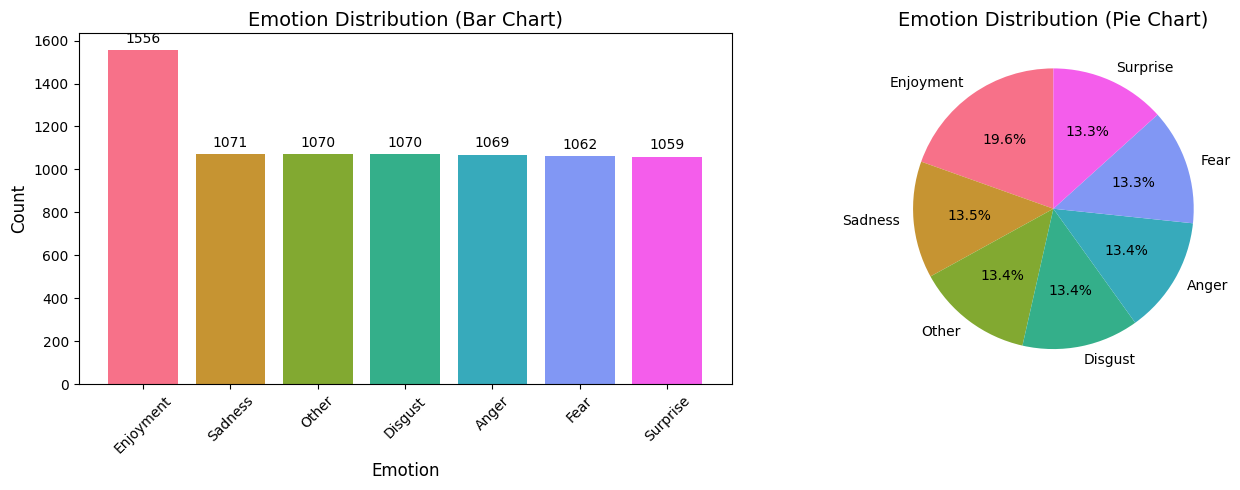

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate emotion distribution
emotion_counts = df['Emotion'].value_counts()

print("=" * 60)
print("EMOTION DISTRIBUTION")
print("=" * 60)
print(f"\n{'Emotion':<15} {'Count':>10} {'Percentage':>12}")
print("-" * 40)

total = len(df)
for emotion, count in emotion_counts.items():
    percentage = (count / total) * 100
    print(f"{emotion:<15} {count:>10} {percentage:>11.2f}%")

print("-" * 40)
print(f"{'TOTAL':<15} {total:>10} {'100.00%':>12}")

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette("husl", len(emotion_counts))
bars = axes[0].bar(emotion_counts.index, emotion_counts.values, color=colors)
axes[0].set_xlabel('Emotion', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Emotion Distribution (Bar Chart)', fontsize=14)
axes[0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, count in zip(bars, emotion_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, 
                 str(count), ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(emotion_counts.values, labels=emotion_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Emotion Distribution (Pie Chart)', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# Shuffle the data
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("Data shuffled successfully!")
print(f"First 5 rows after shuffling:")
print(df.head())


Data shuffled successfully!
First 5 rows after shuffling:
                                            Sentence    Emotion emotion_vn  \
0  Nếu là tui thì chửi sấp mặt, không cần nói nhi...      Anger    giận dữ   
1  dễ thương kinh khủng . bởi vậy mới nói mấy đứa...  Enjoyment     vui vẻ   
2  đến lúc yêu nhạt cực :) tao thề ! kiểu chán ch...    Sadness       buồn   
3              đăng khoa lê lò dầu của mẹ nè anh 😘😘😘  Enjoyment     vui vẻ   
4  tên thì tất nhiên nhớ nhưng ngày sinh của tao ...    Sadness       buồn   

                                      Sentence_clean  
0  nếu là tui thì chửi sấp mặt, không cần nói nhi...  
1  dễ thương kinh khủng . bởi vậy mới nói mấy đứa...  
2  đến lúc yêu nhạt cực vui vẻ tao thề ! kiểu chá...  
3      đăng khoa lê lò dầu của mẹ nè anh hôn hôn hôn  
4  tên thì tất nhiên nhớ nhưng ngày sinh của tao ...  


## 6. Save Preprocessed Data

In [71]:
# Save preprocessed data
output_path = '/Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/train_1071_para_final.csv'
df.to_csv(output_path, index=False)
print(f"Preprocessed data saved to: {output_path}")

# Summary statistics
print("\n" + "=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)
print(f"Total records: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

# Calculate text length statistics
df['original_length'] = df['Sentence'].apply(lambda x: len(str(x)))
df['cleaned_length'] = df['Sentence_clean'].apply(lambda x: len(str(x)))

print(f"\nOriginal text length - Mean: {df['original_length'].mean():.1f}, Max: {df['original_length'].max()}")
print(f"Cleaned text length - Mean: {df['cleaned_length'].mean():.1f}, Max: {df['cleaned_length'].max()}")
print(f"Average reduction: {((df['original_length'].mean() - df['cleaned_length'].mean()) / df['original_length'].mean() * 100):.1f}%")

Preprocessed data saved to: /Users/giahuy/Documents/GitHub/topicmodeling/tm_research/data/processed/train_1071_para_final.csv

PREPROCESSING SUMMARY
Total records: 7957
Columns: ['Sentence', 'Emotion', 'emotion_vn', 'Sentence_clean', 'original_length', 'cleaned_length']

Original text length - Mean: 56.1, Max: 640
Cleaned text length - Mean: 58.0, Max: 639
Average reduction: -3.3%
